In [18]:
#3-16 라이브러리 호출 및 데이터 준비
%matplotlib inline
from sklearn.datasets import load_digits
digits = load_digits() #숫자 데이터샛(digits)은 사이킷런에서 제공

print('Image Data Shape', digits.data.shape) #digits 데이터셋의 형태(이미지가 1797개 있으며 8x8이미지 64차원을 가짐)
print('Label Data Shape', digits.target.shape) #레이블(이미지의 숫자 정보) 이미지 1797개 존재

Image Data Shape (1797, 64)
Label Data Shape (1797,)


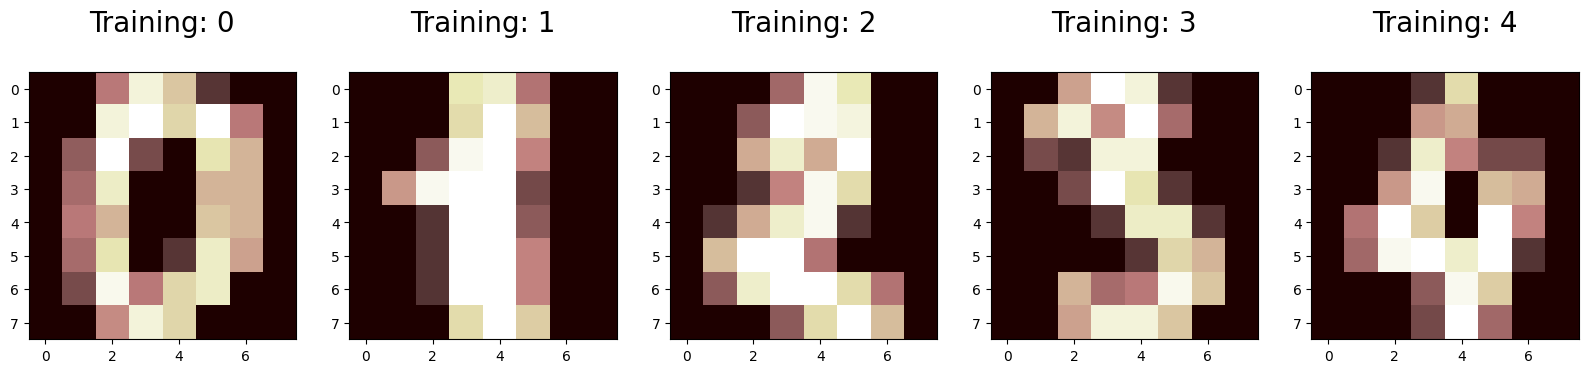

In [15]:
#3-17 digits 데이터셋의 시각화
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(20,4)) # 가로 20인치, 세로 4인치 (전체 5개의 이미지)
#처음엔 한줄로 구성된 기존 digit의 경우 64비트로 구성되어 있음 
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])): #예시로 이미지 다섯 개만 확인
    plt.subplot(1, 5, index+1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.pink)
    plt.title('Training: %i\n' % label, fontsize=20)

In [20]:
#3-18 훈련과 테스트 데이터셋 분리 및 로지스틱 회귀 모델 생성
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25, random_state=0)

from sklearn.linear_model import LogisticRegression
logisticRegr = LogisticRegression(max_iter=1000)  # 기본값 100 → 1000으로
logisticRegr.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [21]:
#3-19 일부 데이터를 사용한 모델 예측
logisticRegr.predict(x_test[0].reshape(1, -1)) #새로운 이미지(테스트 데이터)에 대한 예측 결과를 넘파일 배열로 출력
logisticRegr.predict(x_test[0:10]) #이미지 10개에 대한 예측을 한 번에 배열로 출력

array([2, 8, 2, 6, 6, 7, 1, 9, 8, 5])

In [22]:
#3-20 전체 데이터를 사용한 모델 예측
predictions =logisticRegr.predict(x_test) #전체 데이터셋에 대한 예측
score = logisticRegr.score(x_test, y_test) #스코어(score) 메서드를 사용한 성능 측정
print(score)

0.9533333333333334


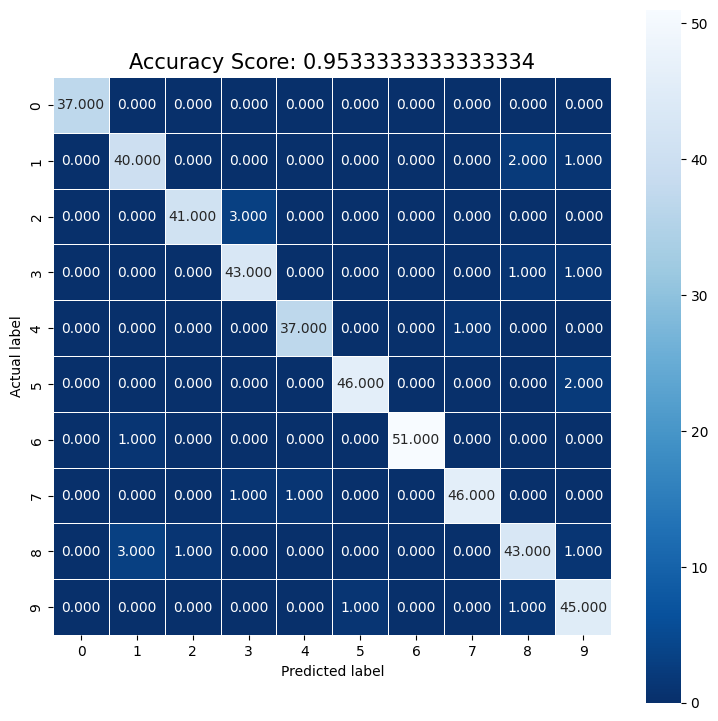

In [26]:
#3-21 혼동 행렬 시각화
import numpy as np
import seaborn as sns
from sklearn import metrics

cm = metrics.confusion_matrix(y_test, predictions) #혼동 행렬(confusion_matrix)
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square=True, cmap='Blues_r'); #heatmap으로 표현

plt.ylabel('Actual label') #y축 텍스트
plt.xlabel('Predicted label') #x축 텍스트
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size=15);
plt.show();